In [1]:
pip install lazypredict


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: C:\Users\tomkn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import plotly.express as px
from lazypredict.Supervised import LazyRegressor
import matplotlib.pyplot as plt
from utils.model import test_train_split, define_features
from config import features, test_start, target

In [3]:
pdf_mvp = pd.read_csv("data/intermediate/time_series_model_data_prep.csv") 

pdf_mvp = pdf_mvp[pdf_mvp["synthetic_flag"] == False]

pdf_mvp = pdf_mvp[pdf_mvp["player_id"] > 0]


In [4]:

features = define_features(pdf_mvp, features)

pdf_train, pdf_test = test_train_split(pdf_mvp, test_start)

In [5]:
def try_lazypredict(pdf_train, pdf_test, features):

    """
    This trys multiple models using LazyPredict and visualizes the results.
    """

    pdf_train = pdf_train[[*features, target]].dropna().reset_index(drop=True)
    print(f" pdf_train after {pdf_train.shape}")
    pdf_test = pdf_test[[*features, target]].dropna().reset_index(drop=True)    
    print(f" pdf_test after {pdf_test.shape}")


    X_train = pdf_train[features]
    y_train = pdf_train[target]

    X_test = pdf_test[features]
    y_test = pdf_test[target]

    # LazyClassifier
    clf = LazyRegressor(verbose=0, ignore_warnings=True)
    models, predictions = clf.fit(X_train, X_test, y_train, y_test)

    # Top 5 models
    print(models.head(5))

    # Assuming `models` is the LazyPredict DataFrame
    top_models = models.sort_values("RMSE", ascending=True).head(20)

    plt.figure(figsize=(10, 6))
    top_models["RMSE"].plot(kind="barh", color="skyblue")
    plt.xlabel("RMSE")
    plt.title("Top 10 Models by RMSE (LazyPredict)")
    plt.gca().invert_yaxis()
    plt.tight_layout()

    acceptable_models = models[models["R-Squared"] > 0]

    fig = px.scatter(acceptable_models, x='R-Squared', y="RMSE", hover_data=[acceptable_models.index], title="Model Performance (LazyPredict)")
    fig.show()




 pdf_train after (12014, 3)
 pdf_test after (1317, 3)


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 191
[LightGBM] [Info] Number of data points in the train set: 12014, number of used features: 2
[LightGBM] [Info] Start training from score 5.806012
                             Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                       
MLPRegressor                               0.84       0.84  6.39        4.62
GradientBoostingRegressor                  0.83       0.83  6.62        0.42
LassoLarsCV                                0.81       0.81  6.87        0.02
Lars                                       0.81       0.81  6.87        0.09
OrthogonalMatchingPursuitCV                0.81       0.81  6.87        0.02


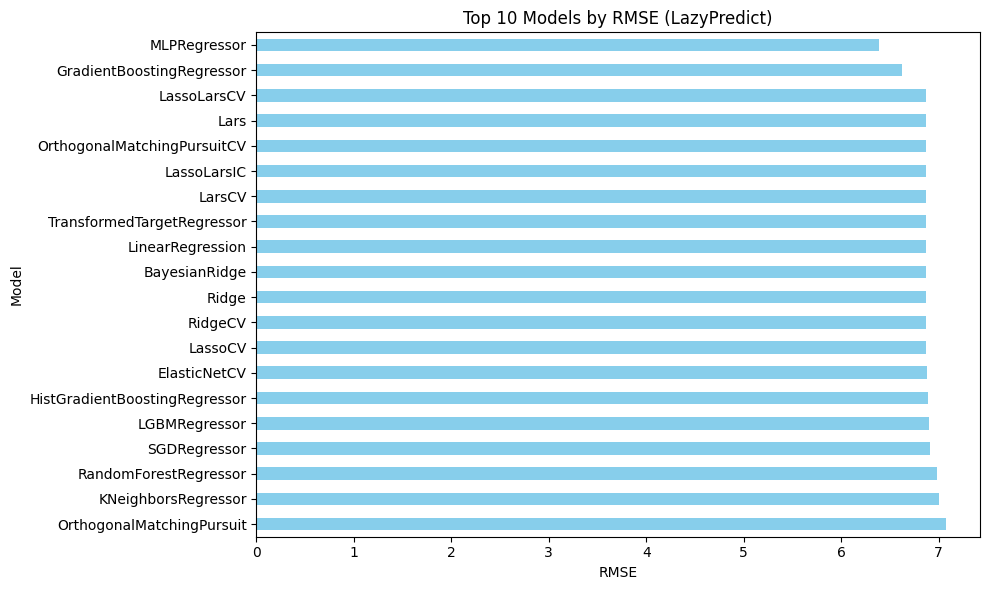

In [6]:
output =  try_lazypredict(pdf_train, pdf_test, ["value_last_year", "age"])

 pdf_train after (6579, 33)
 pdf_test after (953, 33)


  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000742 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1613
[LightGBM] [Info] Number of data points in the train set: 6579, number of used features: 32
[LightGBM] [Info] Start training from score 7.604707
                               Adjusted R-Squared  R-Squared  RMSE  Time Taken
Model                                                                         
MLPRegressor                                 0.86       0.86  6.59        4.39
GradientBoostingRegressor                    0.85       0.85  6.82        1.15
HistGradientBoostingRegressor                0.84       0.85  6.96        0.28
RandomForestRegressor                        0.84       0.85  6.96        3.98
ExtraTreesRegressor                          0.84       0.84  7.10        2.56


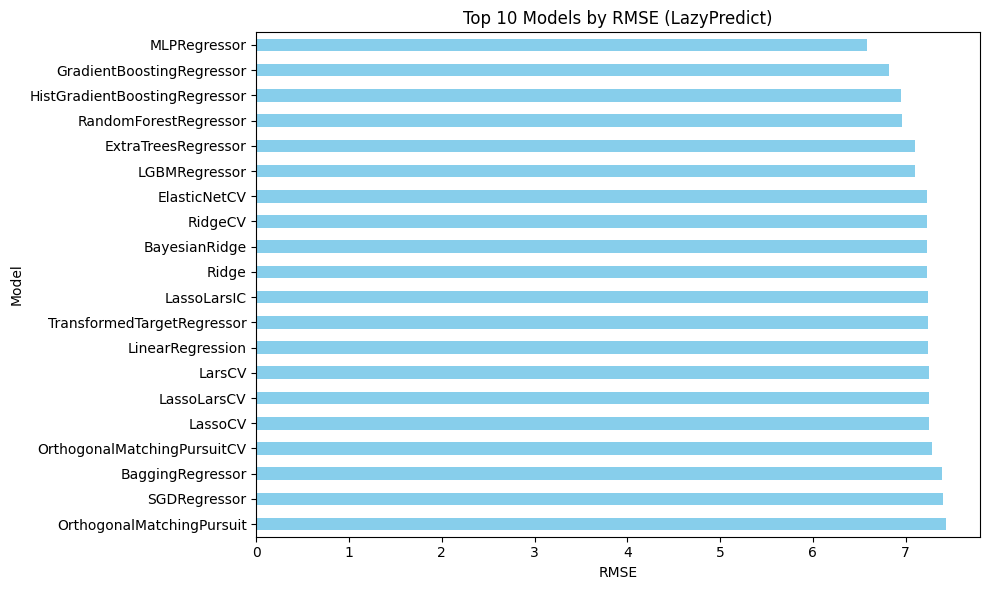

In [7]:
try_lazypredict(pdf_train, pdf_test, features)